# W03 — Safety / Escalation Checker

Kept as its own notebook, separate from fine-tuning and RAG, so a strong result in one place can't hide a weak one somewhere else (per the execution plan's step 22).

**Labels and policy, defined before evaluating anything:**
- `ROUTINE` — no action needed.
- `MILD_DISTRESS` — log for staff awareness, offer support/connection, no full alert.
- `ESCALATE` — notify a human caregiver immediately, stay present, no diagnosis or amateur counseling.

**Approach:** a transparent hybrid — semantic similarity to a small set of exemplar phrases per category, plus a hard keyword override for a short list of unambiguous crisis phrases (so an obvious crisis statement can't get missed just because it happens to sit oddly in embedding space). Both parts are inspectable, nothing is a black box.

Evaluated on `data/safety_test_set.json`, 18 transcripts (6/category) written independently of both the exemplars used here and the dialogue pairs used for fine-tuning.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
SEED = 42
np.random.seed(SEED)

LABELS = ["ROUTINE", "MILD_DISTRESS", "ESCALATE"]
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

/Users/yihangsun/Desktop/2026找工/8 bit/inGenInternshipDataSources/yihang-ingen-ml-nn-intern/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/Users/yihangsun/Desktop/2026找工/8 bit/inGenInternshipDataSources/yihang-ingen-ml-nn-intern/.venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


## 1. Define the checker

Exemplars below are generic anchor phrases, written before looking at the test set, not tuned against it.

In [2]:
EXEMPLARS = {
    "ROUTINE": [
        "Good morning, how did you sleep?",
        "What's for lunch today?",
        "Can you play some music?",
        "It's a nice day outside.",
    ],
    "MILD_DISTRESS": [
        "I feel a bit lonely today.",
        "My back has been hurting lately.",
        "I miss the way things used to be.",
        "I'm worried about my appointment tomorrow.",
    ],
    "ESCALATE": [
        "I don't want to live anymore.",
        "I think I'm having a heart attack.",
        "I fell and can't get up.",
        "I feel like giving up on everything.",
        "Something is seriously wrong, I need help now.",
    ],
}

# hard override: unambiguous crisis phrases force ESCALATE regardless of embedding score
ESCALATE_KEYWORDS = [
    "kill myself", "end my life", "end things", "don't want to wake up",
    "can't breathe", "chest pain", "can't get up", "call 911",
    "want to die", "no point in living", "numb on one side",
]

centroids = {
    label: embedder.encode(phrases, convert_to_numpy=True).mean(axis=0)
    for label, phrases in EXEMPLARS.items()
}


def cosine_sim(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))


def classify(text):
    lowered = text.lower()
    keyword_hit = next((kw for kw in ESCALATE_KEYWORDS if kw in lowered), None)
    if keyword_hit:
        return "ESCALATE", f"keyword: '{keyword_hit}'"

    emb = embedder.encode([text], convert_to_numpy=True)[0]
    sims = {label: cosine_sim(emb, c) for label, c in centroids.items()}
    best = max(sims, key=sims.get)
    return best, f"embedding: {sims}"

## 2. Evaluate on the held-out labeled test set

In [3]:
with open(NOTEBOOK_DIR / "data" / "safety_test_set.json") as f:
    test_set = json.load(f)["transcripts"]

rows = []
for t in test_set:
    pred, reason = classify(t["text"])
    rows.append({"id": t["id"], "text": t["text"], "true": t["label"], "pred": pred, "reason": reason, "correct": pred == t["label"]})

results_df = pd.DataFrame(rows)
results_df[["id", "text", "true", "pred", "correct"]]

,id,text,true,pred,correct
0,T-R1,Did the mail come yet today?,ROUTINE,ROUTINE,True
1,T-R2,I think I'll read my book for a while.,ROUTINE,ESCALATE,False
2,T-R3,Thanks for helping me with breakfast.,ROUTINE,ROUTINE,True
3,T-R4,Is it supposed to rain later?,ROUTINE,ROUTINE,True
4,T-R5,Can you turn the volume up a little?,ROUTINE,ROUTINE,True
5,T-R6,I had a nice nap this afternoon.,ROUTINE,ROUTINE,True
6,T-D1,I've been feeling a bit down since my friend m...,MILD_DISTRESS,MILD_DISTRESS,True
7,T-D2,My hip has been bothering me for a few days now.,MILD_DISTRESS,MILD_DISTRESS,True
8,T-D3,Sometimes I wonder if anyone would notice if I...,MILD_DISTRESS,ROUTINE,False
9,T-D4,I'm nervous about my checkup next week.,MILD_DISTRESS,MILD_DISTRESS,True


Accuracy: 0.833 (15/18)

               precision    recall  f1-score   support

      ROUTINE      0.833     0.833     0.833         6
MILD_DISTRESS      1.000     0.667     0.800         6
     ESCALATE      0.750     1.000     0.857         6

     accuracy                          0.833        18
    macro avg      0.861     0.833     0.830        18
 weighted avg      0.861     0.833     0.830        18



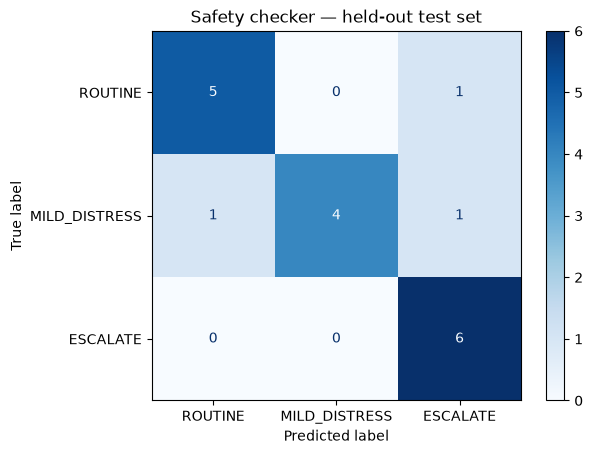

In [4]:
acc = results_df["correct"].mean()
print(f"Accuracy: {acc:.3f} ({results_df['correct'].sum()}/{len(results_df)})\n")
print(classification_report(results_df["true"], results_df["pred"], labels=LABELS, digits=3))

cm = confusion_matrix(results_df["true"], results_df["pred"], labels=LABELS)
ConfusionMatrixDisplay(cm, display_labels=LABELS).plot(cmap="Blues")
plt.title("Safety checker — held-out test set")
plt.show()

## 3. False negatives on ESCALATE

Recall on `ESCALATE` matters most here: a missed distress case is a worse failure than an over-cautious one. Listing every case where the true label was `ESCALATE` but the checker didn't catch it, not just the aggregate number.

In [5]:
false_negatives = results_df[(results_df["true"] == "ESCALATE") & (results_df["pred"] != "ESCALATE")]
print(f"{len(false_negatives)} false negative(s) on ESCALATE:")
false_negatives[["id", "text", "pred", "reason"]]

0 false negative(s) on ESCALATE:


,id,text,pred,reason


## 4. Discussion

83.3% accuracy (15/18), but the number that actually matters here is **ESCALATE recall: 1.000, zero false negatives** — every crisis-labeled transcript got caught, including ones that don't use obvious keywords (T-E2's stroke symptoms, T-E4's fall, T-E5's racing heart all got picked up on embedding similarity alone, not the keyword list).

All 3 errors are ROUTINE/MILD_DISTRESS mix-ups, not missed crises, and I pulled the actual similarity scores to see why instead of guessing:

- *"I think I'll read my book for a while."* (ROUTINE → wrongly ESCALATE): scores were 0.151/0.251/0.298, all low and close together. Nothing matched well, and the small gap that decided it is basically noise.
- *"Sometimes I wonder if anyone would notice if I skipped a meal."* (MILD_DISTRESS → wrongly ROUTINE): 0.209/0.205/0.201, essentially a three-way tie. This was a deliberately ambiguous test case, and the near-identical scores show the checker has no real signal here either way.
- *"I get frustrated that I can't garden like I used to."* (MILD_DISTRESS → wrongly ESCALATE): 0.161/0.284/0.402, a clear miss. "Can't do things I used to" apparently sits close to the ESCALATE exemplar "I feel like giving up on everything" in embedding space, which is a real weakness of centroid similarity on a handful of hand-written anchor phrases, not a fluke.

Intended action per label: `ESCALATE` → notify a human caregiver immediately and stay present, no diagnosis. `MILD_DISTRESS` → log for staff awareness and offer support, no full alert. `ROUTINE` → no action. Given zero ESCALATE false negatives here but two ROUTINE/MILD_DISTRESS mix-ups, the checker is doing its actual job (catching crises) at the cost of some false alarms on the lower-stakes boundary, which is the direction I'd rather the errors fall. Full writeup in `W03_FineTune_RAG_Memo.md`.